In [6]:
import shap
import numpy as np
import keras
import joblib
import matplotlib.pyplot as plt

classifier = keras.models.load_model('../models/classifier.keras')
le = joblib.load('../data/label_encoder.pkl')
ct = joblib.load('../data/column_transformer.pkl')

X_all = np.load('../data/X_train.npy')
anomaly_flags = np.load('../data/anomaly_flags.npy')
X_flagged = X_all[anomaly_flags == 1]

In [3]:
# background = small reference sample the explainer compares against
background = X_flagged[:200]
X_sample = X_flagged[200:600]   # 400 samples to explain

explainer = shap.GradientExplainer(classifier, background)
shap_values = explainer.shap_values(X_sample)

# shap_values is a list of 23 arrays, one per class
# each array shape: (400, 122)
print(f"Number of classes: {len(shap_values)}")
print(f"Shape per class: {shap_values[0].shape}")

/Users/shivaram/network-anomaly-detection-ids/ids-env/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(400, 122))']
  warnings.warn(msg)
/Users/shivaram/network-anomaly-detection-ids/ids-env/lib/python3.11/site-packages/keras/src/models/functional.py:258: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_3
Received: inputs=['Tensor(shape=(50, 122))']
  warnings.warn(msg)


Number of classes: 400
Shape per class: (122, 23)


In [7]:
print(type(shap_values))
if isinstance(shap_values, list):
    print(f"List of {len(shap_values)} arrays")
    print(f"Each array shape: {shap_values[0].shape}")
else:
    print(f"Array shape: {np.array(shap_values).shape}")
print(f"X_sample shape: {X_sample.shape}")

<class 'numpy.ndarray'>
Array shape: (400, 122, 23)
X_sample shape: (400, 122)


In [4]:
feature_names = ct.get_feature_names_out()
print(f"Total features: {len(feature_names)}")

Total features: 122


/var/folders/k5/b7jbvgl52d3cdhz1ftnhwcj40000gn/T/ipykernel_1608/3109818735.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


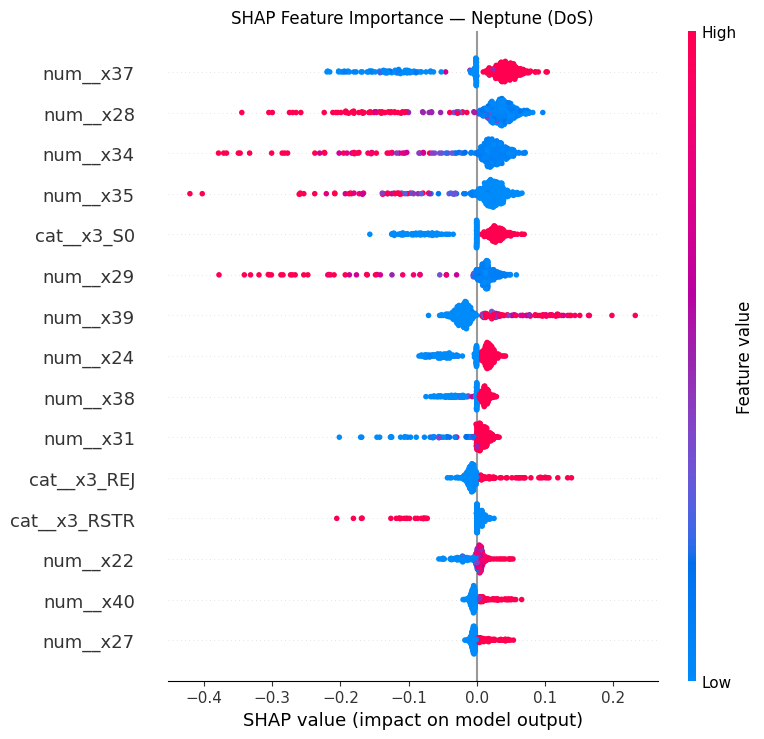

In [8]:
plt.figure()
shap.summary_plot(
    shap_values[:, :, 9],
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance — Neptune (DoS)")
plt.tight_layout()
plt.savefig('../models/shap_neptune.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/k5/b7jbvgl52d3cdhz1ftnhwcj40000gn/T/ipykernel_1608/4260063369.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


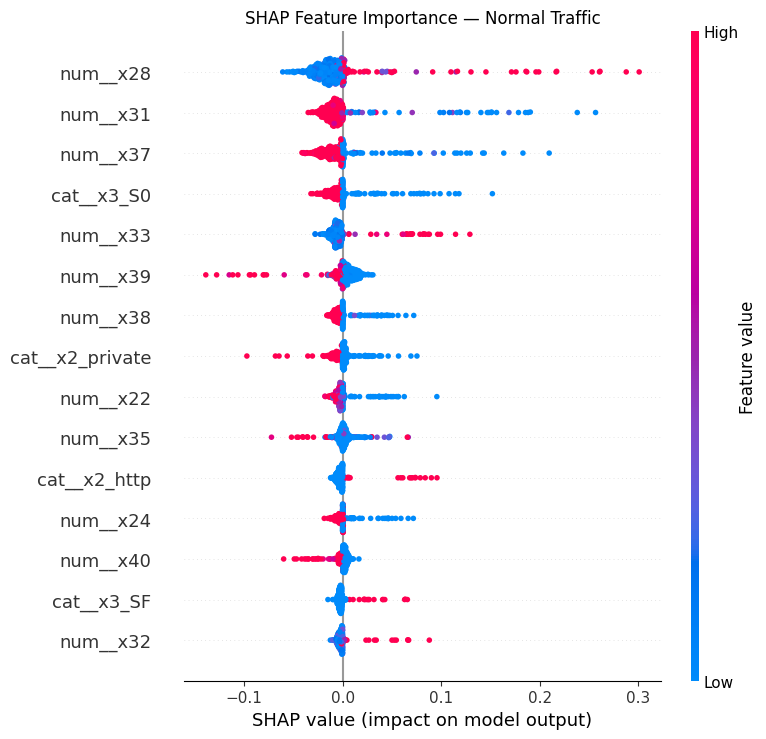

In [9]:
plt.figure()
shap.summary_plot(
    shap_values[:, :, 11],
    X_sample,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP Feature Importance — Normal Traffic")
plt.tight_layout()
plt.savefig('../models/shap_normal.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
np.save('../data/shap_values.npy', np.array(shap_values))
np.save('../data/X_sample.npy', X_sample)
print("SHAP values saved")

SHAP values saved
